In [69]:
import sys
from pathlib import Path

# add parent directory to Python path
parent_dir = Path.cwd().parent
sys.path.append(str(parent_dir))

import numpy as np
import matplotlib.pyplot as plt
from scipy.sparse.linalg import eigsh
from scipy.linalg import norm
import pandas as pd
from scipy import stats
from src.dgp import GaussianNetwork
from src.methods import ASE, LLKRatioTest

In [70]:
rng = np.random.default_rng()
n = 100
k = 5
sigma = 0
nsim = 10000
rejected = 0

for i in range(nsim):
    md = GaussianNetwork(
        n=n,
        k=k,
        sigma=sigma,
        marginal_z=stats.norm,
        marginal_x=stats.norm,
        rng=rng,
        edge_var=1,
    )
    A, B, X, Z = md.generate()

    test = LLKRatioTest(sigma=0, alpha=0.05, rng=rng)
    test.fit(A, B, k=5, approximation="chi-sq")
    rejected += test.get_estimated()

rejected / nsim

KeyboardInterrupt: 

In [15]:
from dgp import generate_gaussian_data
from methods import (
    solve_independent,
    aggregate_results,
    solve_dependent,
    objective_function,
    solver_grid,
)
from metrics import rv_coefficient, mse, relative_frobenius_norm
from plot_functions import plot_grid, plot_with_bands

In [36]:
from simulation_functions import run_simulation

nsim = 10
n = [100, 200]
sigma = 0.5
edge_var = [1]
k = [3]
step_size = [1, 1e-1, 1e-2]
rng = np.random.default_rng(1)
metrics = {"matrix": [relative_frobenius_norm], "scalar": [mse]}

out = run_simulation(
    nsim=nsim,
    n=n,
    k=k,
    sigma=sigma,
    edge_var=edge_var,
    dgp=generate_gaussian_data,
    metrics=metrics,
    rng=rng,
    solver=solve_dependent,
    step_size=step_size,
    parallel=True,
    niters=200,
)

Simulation 1 of 10


Running scenarios: 100%|██████████| 6/6 [00:37<00:00,  6.28s/it]

Simulation 2 of 10



Running scenarios: 100%|██████████| 6/6 [00:33<00:00,  5.58s/it]

Simulation 3 of 10


...


Running scenarios: 100%|██████████| 6/6 [00:31<00:00,  5.28s/it]

Simulation 9 of 10



Running scenarios: 100%|██████████| 6/6 [00:29<00:00,  4.94s/it]

Simulation 10 of 10



Running scenarios: 100%|██████████| 6/6 [00:31<00:00,  5.29s/it]


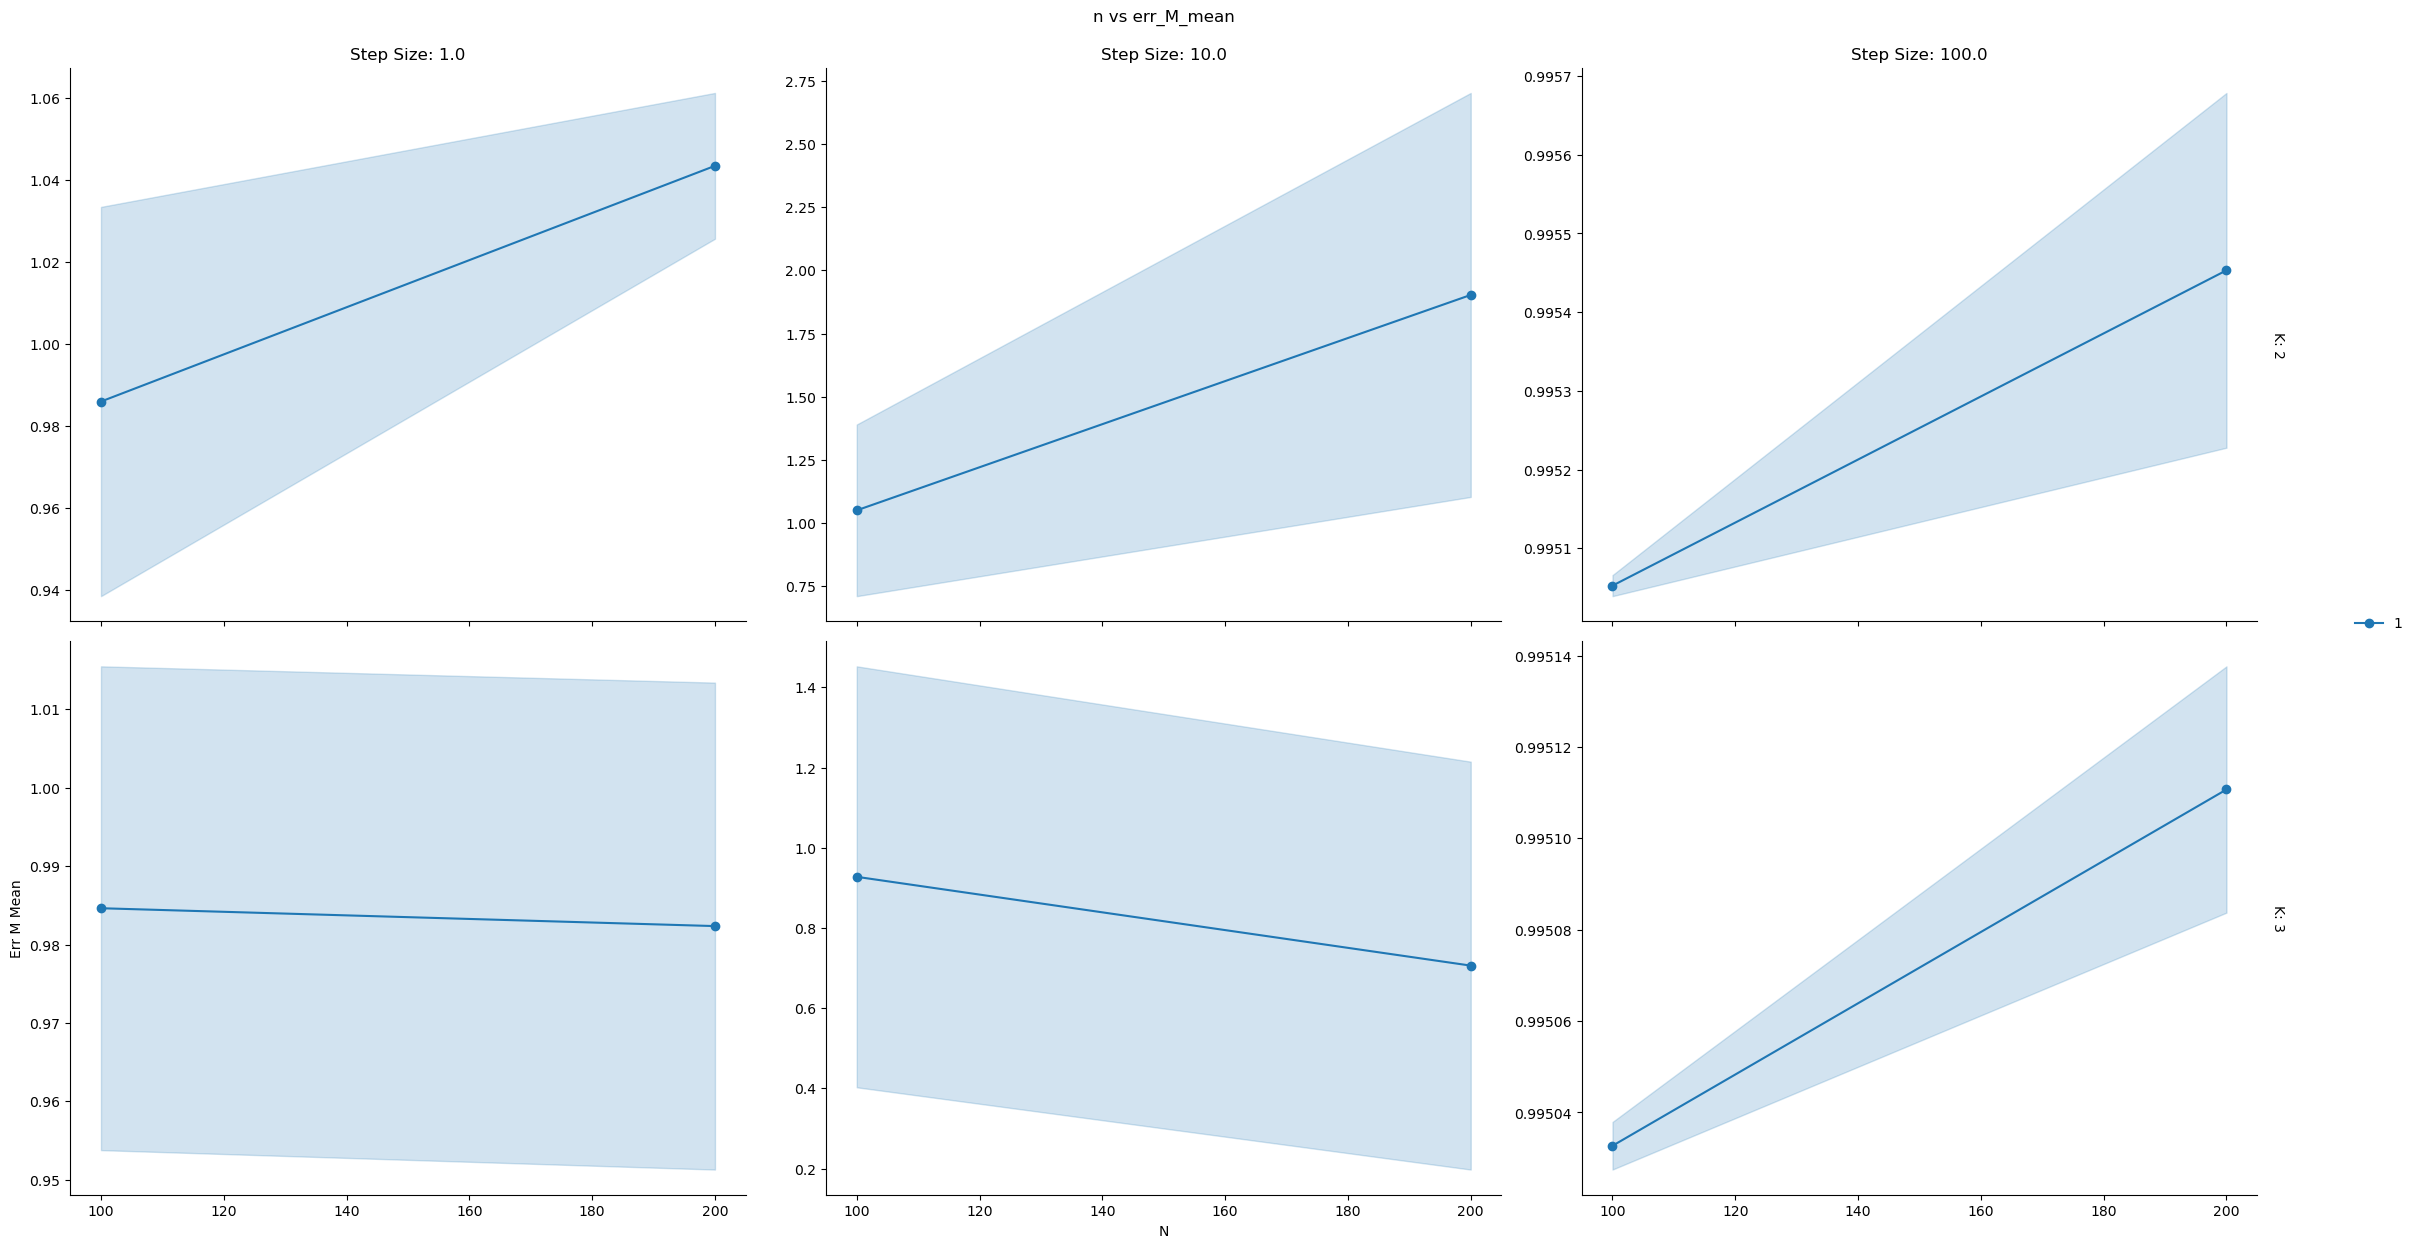

In [34]:
out = pd.DataFrame(out)
out_M = out.drop(columns=["err_sigma"])
out_M["err_M"] = out_M["err_M"].apply(lambda x: x[0])  # extract first element from list
out_sigma = out.drop(columns=["err_M"])
out_sigma["err_sigma"] = out_sigma["err_sigma"].apply(
    lambda x: x[0]
)  # extract first element from list

agg_out_M = aggregate_results(
    out_M, y_axis="err_M", x_axis="n", factors=["step_size", "edge_var", "k"]
)
agg_out_sigma = aggregate_results(
    out_sigma, y_axis="err_sigma", x_axis="n", factors=["step_size", "edge_var", "k"]
)

plot_grid(
    grouped_stats=agg_out_M,
    plotting_function=plot_with_bands,
    x_axis="n",
    y_axis="err_M_mean",
    factors=["edge_var", "step_size", "k"],
    height=6,
    se_bands="err_M_sem",
    share_x=True,
    share_y=False,
)

In [35]:
agg_out_M

,n,step_size,edge_var,k,err_M_mean,err_M_sem
0,100,1.0,1,2,0.985903,0.047457
1,100,1.0,1,3,0.984637,0.030856
2,100,10.0,1,2,1.050339,0.339643
3,100,10.0,1,3,0.927573,0.524896
4,100,100.0,1,2,0.995052,0.000013
5,100,100.0,1,3,0.995033,0.000005
6,200,1.0,1,2,1.043373,0.017776
7,200,1.0,1,3,0.982359,0.031058
8,200,10.0,1,2,1.902747,0.799422
9,200,10.0,1,3,0.706133,0.508622


In [ ]:
# rng = np.random.default_rng()
# n = 100
# k = 3
# sigma = 0
# edge_var = 1
# A, B, Z, X = generate_gaussian_data(n=n, k=k, sigma=sigma, edge_var=edge_var, rng=rng)
# M = np.block([[Z@Z.T, X@Z.T], [Z@X.T, X@X.T]])

# niters = 200
# step_size=10

# llk_val, Ms, sigmas = solver_grid(A, B, k, niters, grid=0.25, rng=rng)

In [ ]:
# errs = {
#     k: [relative_frobenius_norm(Ms[k][i], M) for i in range(len(Ms[k]))] for k in sigmas
# }

# fig, ax = plt.subplots(figsize=(6, 4))
# for k, v in errs.items():
#     ax.plot(v, label=f'Sigma: {k}')
# ax.set_xlabel('Iteration')
# ax.set_ylabel('Relative Frobenius Norm')
# ax.legend()
# plt.show()

In [ ]:
rng = np.random.default_rng(1)
n = 100
k = 2
sigma = 0.99
edge_var = 1
niters = 500
delta_reg = 0.309
step_size = 0.5
lambda_reg = 0

A, B, Z, X = generate_gaussian_data(n=n, k=k, sigma=sigma, edge_var=edge_var, rng=rng)
M = np.block([[Z @ Z.T, X @ Z.T], [X @ Z.T, X @ X.T]])

Ms, sigmas = solve_dependent(
    A,
    B,
    k=k,
    niters=niters,
    rng=rng,
    fit_sigma=True,
    sigma=None,
    delta_reg=delta_reg,
    step_size=step_size,
    lambda_reg=0,
)

errs_M = [relative_frobenius_norm(Ms[i], M) for i in range(len(Ms))]
errs_sigma = [np.abs(np.abs(sigmas[i]) - np.abs(sigma)) for i in range(len(sigmas))]

lambda_reg = (2 + delta_reg) * np.sqrt(2 * n)

obj_out = []
for i in range(len(Ms)):
    t = objective_function(n, k, Ms[i], A, B, sigma=sigmas[i], lambda_reg=0)
    obj_out.append(t)

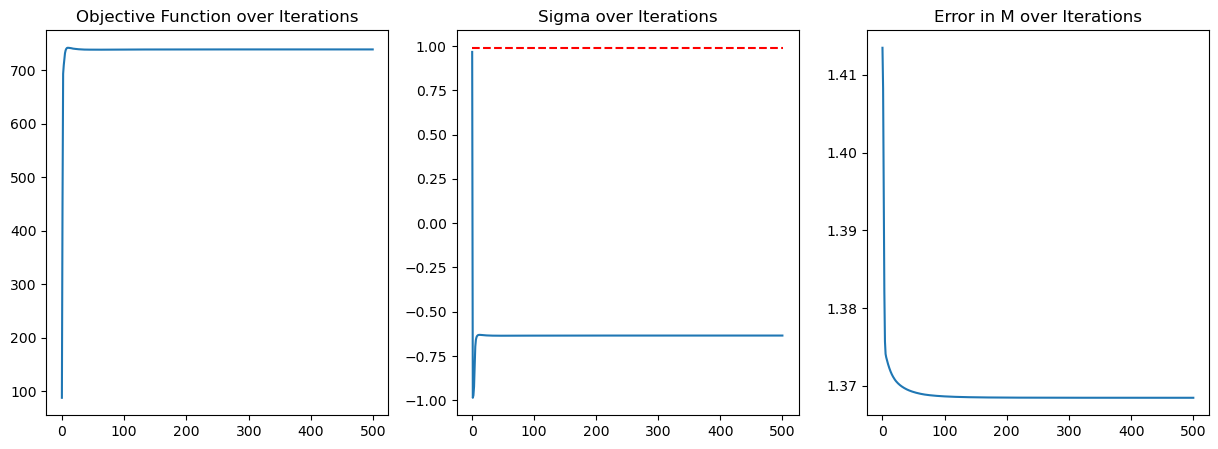

In [ ]:
fig, ax = plt.subplots(1, 3, figsize=(15, 5))
ax[0].set_title("Objective Function over Iterations")
ax[0].plot(obj_out[1:], label="Objective Function")
ax[1].set_title("Sigma over Iterations")
ax[1].plot(sigmas, label="Sigma")
ax[1].hlines(sigma, xmin=0, xmax=len(sigmas), colors="r", linestyles="dashed")
ax[2].set_title("Error in M over Iterations")
ax[2].plot(errs_M, label="Error in M")
# plt.legend()
plt.show()

In [ ]:
np.allclose(X @ Z.T, (Z @ X.T).T)

True

In [ ]:
from methods import llk_gradient

llk_gradient(M, A, B, sigma, n), llk_gradient(Ms[-1], A, B, sigmas[-1], n)

(array([[107.23551705,  -4.83914024,   2.51291955, ...,   0.        ,
           0.        ,   0.        ],
        [ -4.83914024,  95.04318952,  -1.83911461, ...,   0.        ,
           0.        ,   0.        ],
        [  2.51291955,  -1.83911461,  97.11224029, ...,   0.        ,
           0.        ,   0.        ],
        ...,
        [  0.        ,   0.        ,   0.        , ...,  99.19489524,
           2.26426604,  -1.41099213],
        [  0.        ,   0.        ,   0.        , ...,   2.26426604,
         102.19868057,   5.24081558],
        [  0.        ,   0.        ,   0.        , ...,  -1.41099213,
           5.24081558, 105.88868837]], shape=(100, 100)),
 array([[13.9175947 , -4.43661834,  2.08916819, ...,  0.        ,
          0.        ,  0.        ],
        [-4.43661834,  8.62546279, -0.06030215, ...,  0.        ,
          0.        ,  0.        ],
        [ 2.08916819, -0.06030215,  9.36733759, ...,  0.        ,
          0.        ,  0.        ],
        ...,


In [ ]:
from methods import llk_gradient

(
    llk_gradient(M, A, B, 0.5, n),
    llk_gradient(Ms[1], A, B, 0.5, n),
)

(array([[ 8.48665026, -3.4847402 ,  3.13530843, ...,  0.        ,
          0.        ,  0.        ],
        [-3.4847402 ,  1.17562802,  0.38078356, ...,  0.        ,
          0.        ,  0.        ],
        [ 3.13530843,  0.38078356,  5.46311655, ...,  0.        ,
          0.        ,  0.        ],
        ...,
        [ 0.        ,  0.        ,  0.        , ...,  2.69215026,
         -0.16253323,  4.19429663],
        [ 0.        ,  0.        ,  0.        , ..., -0.16253323,
          3.48081469, -0.11770724],
        [ 0.        ,  0.        ,  0.        , ...,  4.19429663,
         -0.11770724,  5.95740446]], shape=(400, 400)),
 array([[35.33729013,  0.58348053, -0.89072398, ...,  0.        ,
          0.        ,  0.        ],
        [ 0.58348053, 33.2357832 , -0.48087974, ...,  0.        ,
          0.        ,  0.        ],
        [-0.89072398, -0.48087974, 35.10492745, ...,  0.        ,
          0.        ,  0.        ],
        ...,
        [ 0.        ,  0.        ,  

In [ ]:
np.block([[np.zeros_like(M[:n, :n]), M[:n, n:]], [M[n:, :n], np.zeros_like(M[n:, n:])]])

array([[ 0.        ,  0.        ,  0.        , ...,  1.07750578,
        -0.99726528,  1.38248138],
       [ 0.        ,  0.        ,  0.        , ..., -0.04139616,
        -1.5398645 ,  0.79840594],
       [ 0.        ,  0.        ,  0.        , ...,  0.24195064,
        -0.77574286, -1.54581544],
       ...,
       [-0.42702891, -0.50640838,  0.52785894, ...,  0.        ,
         0.        ,  0.        ],
       [ 2.3778416 ,  0.64087085, -0.30974033, ...,  0.        ,
         0.        ,  0.        ],
       [-1.82881448, -0.18211481,  0.4762939 , ...,  0.        ,
         0.        ,  0.        ]], shape=(400, 400))

In [ ]:
objective_function(
    n,
    k,
    np.block(
        [[np.zeros_like(M[:n, :n]), M[:n, n:]], [M[n:, :n], np.zeros_like(M[n:, n:])]]
    ),
    A,
    B,
    sigma=0.1,
    lambda_reg=lambda_reg,
)

np.float64(55420.91365582353)

In [ ]:
Ms[-1].sum(), Ms[-2].sum()

(np.float64(7549.85237452929), np.float64(7562.624820287671))

In [ ]:
out_M = out.drop(columns=["err_sigma"])
out_sigma = out.drop(columns=["err_M"])

agg_out_M = aggregate_results(
    out_M, y_axis="err_M", x_axis="n", factors=["step_size", "edge_var", "k"]
)
agg_out_sigma = aggregate_results(
    out_sigma, y_axis="err_sigma", x_axis="n", factors=["step_size", "edge_var", "k"]
)

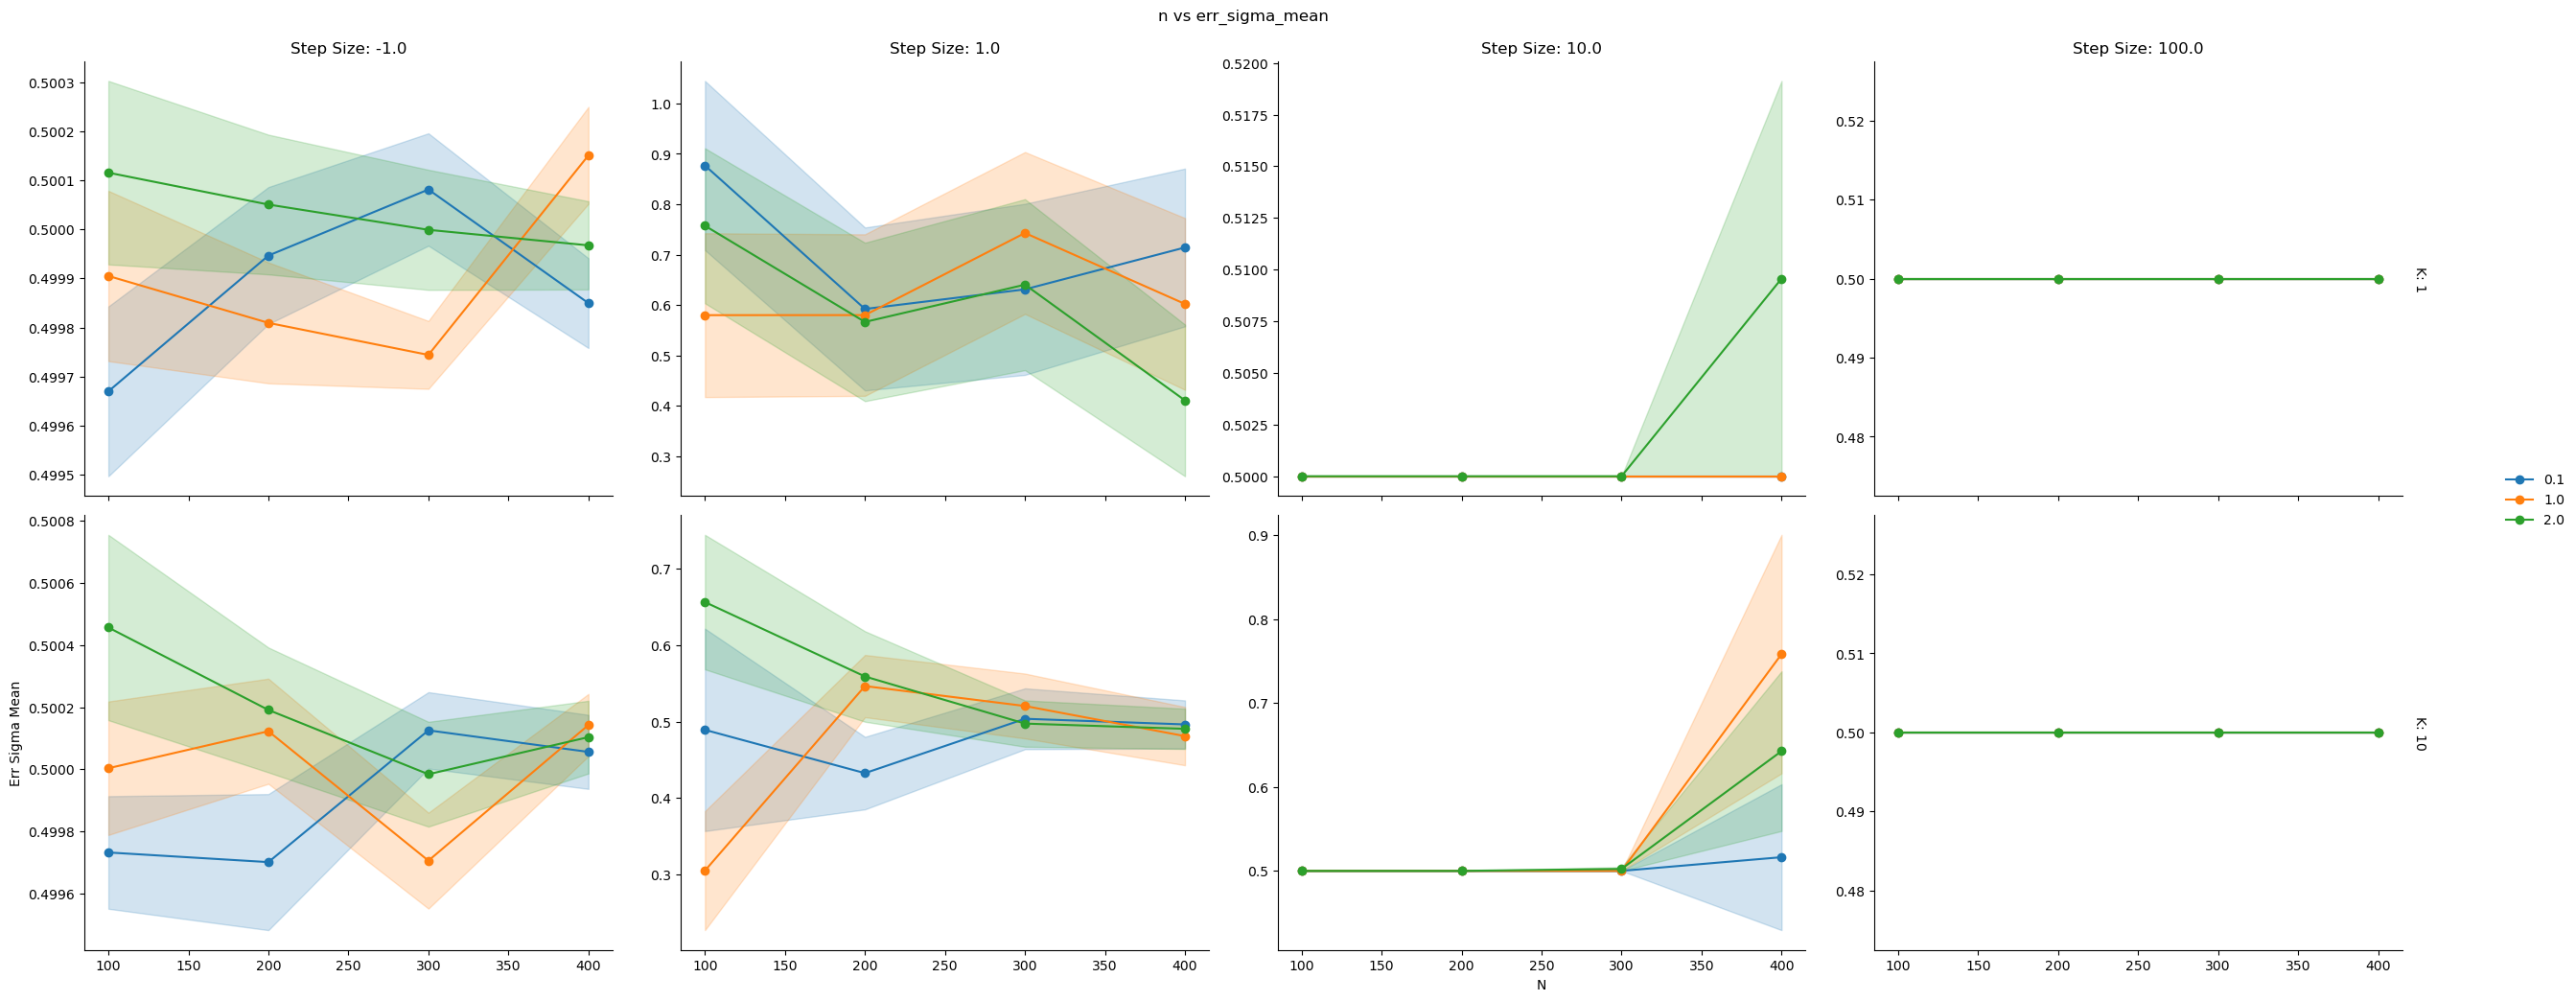

In [ ]:
out_M = out.drop(columns=["err_sigma"])
out_sigma = out.drop(columns=["err_M"])

agg_out_M = aggregate_results(
    out_M, y_axis="err_M", x_axis="n", factors=["step_size", "edge_var", "k"]
)
agg_out_sigma = aggregate_results(
    out_sigma, y_axis="err_sigma", x_axis="n", factors=["step_size", "edge_var", "k"]
)

plot_grid(
    grouped_stats=agg_out_sigma,
    plotting_function=plot_with_bands,
    x_axis="n",
    y_axis="err_sigma_mean",
    factors=["edge_var", "step_size", "k"],
    height=5,
    se_bands="err_sigma_sem",
    share_x=True,
    share_y=False,
)

In [ ]:
out.groupby("n").mean()[["err_M", "err_sigma"]]

,err_M,err_sigma
n,,
100,249.891910,0.527706
200,250.274400,0.511538
300,248.134223,0.522429
400,248.021194,0.525935


#### Independence test

In [ ]:
rng = np.random.default_rng(1)
n = 50
k = 5
edge_var = 5
sigma = 0

A, B, Z, X = generate_gaussian_data(n, k, sigma, edge_var=edge_var, rng=rng)

Zhat, evals_A = solve_independent(A, k=k)
Xhat, evals_B = solve_independent(B, k=k)
rv_est = rv_coefficient(Zhat, Xhat)
rv_coefficient(A, B), rv_coefficient(Zhat, Xhat), rv_coefficient(Z, X)

(np.float64(0.3578749432547567),
 np.float64(0.11070601134747417),
 np.float64(0.1069607284028805))

In [ ]:
n_perm = 100
rv_distr = []
for i in range(n_perm):
    perm = rng.permutation(n)
    X_perm = X[perm, :]
    rv_perm = rv_coefficient(X_perm, Z)
    rv_distr.append(rv_perm)

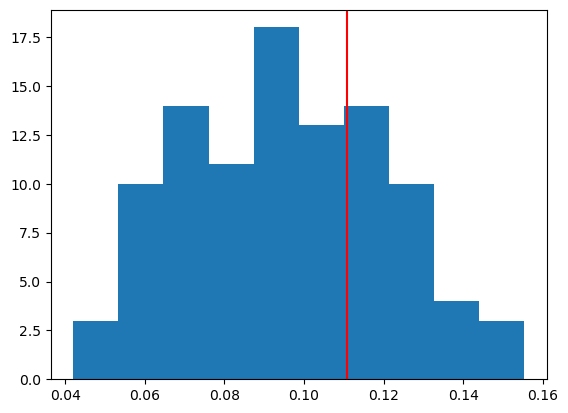

In [ ]:
fig, ax = plt.subplots()
ax.hist(rv_distr)
ax.axvline(rv_est, color="red")
plt.show()